In [44]:
import glob
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe

import sys
sys.path.append('..')
import ssefcca_functions as sfc

In [45]:
data_folder = '../data'
csv_folder = f'{data_folder}/csv_files'
acc_folder = f'{csv_folder}/benchmarking/accuracies'
bsl_folder = f'{csv_folder}/benchmarking/bsl'

plots_folder = f'{data_folder}/plots/comparisons'

In [46]:
def acc_df(models,raw,bal,chance_bal,path):
    df = {
        'model':models,
        'mean_accuracy':[np.mean(raw[x]) for x in raw],
        'std_accuracy':[np.std(raw[x]) for x in raw],
        'median_accuracy':[np.median(raw[x]) for x in raw],
        'mean_balanced_accuracy':[np.mean(bal[x]) for x in bal],
        'std_balanced_accuracy':[np.std(bal[x]) for x in bal],
        'median_balanced_accuracy':[np.median(bal[x]) for x in bal],
        'mean_chance_balanced_accuracy':[np.mean(chance_bal[x]) for x in chance_bal],
        'std_chance_balanced_accuracy':[np.std(chance_bal[x]) for x in chance_bal],
        'median_chance_balanced_accuracy':[np.median(chance_bal[x]) for x in chance_bal]
    }
    df = pd.DataFrame(df)
    df.to_csv(path, index=False)

    return df

def set_y_ticks(data_dict, ax, major_ticks_interval=1, minor_ticks_interval=5, rounding=0):
    '''
    Set y-axis tick marks with automatic limits based on data range.
    
    Parameters:
    -----------
    data_dict : dict
        Data dictionary to determine axis limits
    ax : matplotlib axis
        Axis object to modify
    major_ticks_interval : float
        Spacing for major tick marks
    minor_ticks_interval : float
        Spacing for minor tick marks
    rounding : int
        Decimal places for rounding the lower limit
    '''
    # Calculate y-axis limits based on data minimum
    rounded_min = np.round(np.min(list(data_dict.values())),rounding)
    rounded_min = rounded_min - (rounded_min % major_ticks_interval) - major_ticks_interval

    ylim = (rounded_min, 100)
    ax.set_ylim(ylim)
    
    # Set major and minor tick marks
    ax.set_yticks(np.arange(np.round(np.floor(1e2 * ylim[0]) / 1e2, 1), ylim[1] + 1e-2, major_ticks_interval))
    ax.tick_params(axis='y', which='minor')
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(minor_ticks_interval))

### For the comparison plots ###
# Color mapping for different model categories
boxplot_colors_dict = {
    'Literature Models': 'gold',
    'Unweighted Supervised\nClassifier Models': 'lightcoral',
    'Weighted Supervised\nClassifier Models': 'skyblue',
}
zero_rule_colour = 'grey'  # Baseline model color

def model_colour(model):
    '''Assign color to a model based on its type.'''
    if any([x in model for x in ['(W)']]):
        return boxplot_colors_dict['Weighted Supervised\nClassifier Models']
    elif any([x in model for x in ['DBCCR', '3D MSCC', 'Hybrid', '3D Hybrid']]):
        return boxplot_colors_dict['Literature Models']
    elif any([x in model for x in ['(U)', '$k$NN', 'KNN', 'kNN']]):
        return boxplot_colors_dict['Unweighted Supervised\nClassifier Models']
    else:
        return zero_rule_colour

# Available plot types
plot_type = {
    'boxplot': sfc.draw_boxplot,
    'violinplot': sfc.draw_violinplot
}

def comparison_plots(raw,bal,chance,
                     pah_yn:bool,hide_unweighted=True,close:bool=False):

    data_dict = {
        'raw': raw,  # Standard accuracy
        'balanced': bal,  # Balanced accuracy (accounts for class imbalance)
        'chance': chance  # Chance-adjusted balanced accuracy
    }

    def ru_bool(x):
        '''Check if model uses Rivas-Ubach category definitions.'''
        return 'R-U' in x or ('MSCC' in x and 'Adjusted' not in x)

    hide_unweighted = hide_unweighted  # Option to simplify plots by hiding unweighted models

    for plot_choice in plot_type:
        for acc_type in data_dict.keys():
            
            # Set y-axis label based on accuracy type
            if acc_type == 'raw':
                ylabel = 'Accuracy'
                data_to_use = data_dict[acc_type]
            
            elif acc_type == 'balanced':
                ylabel = 'Balanced Accuracy'
                data_to_use = data_dict[acc_type]
            
            elif acc_type == 'chance':
                ylabel = 'Balanced Accuracy\nAdjusted for Chance'
                data_to_use = data_dict[acc_type]

            if hide_unweighted and acc_type != 'raw':
                data_to_use = {x: data_to_use[x] for x in data_to_use if '(U)' not in x}

            ru = [False] if pah_yn else [False, True]
            for ru_defs in ru:
            
                if ru_defs:
                    # Filter for Rivas-Ubach definition models
                    data_to_use_ru = {x.replace(' (R-U)', ''): data_to_use[x] for x in data_to_use.keys() if ru_bool(x) or x == 'Zero Rule'}
                else:
                    # Filter for standard definition models
                    data_to_use_ru = {x: data_to_use[x] for x in data_to_use.keys() if not ru_bool(x)}
    
                # Assign colors based on model type
                boxplot_colors = [model_colour(x) for x in data_to_use_ru.keys()]
    
                # Simplify model names if hiding unweighted
                if acc_type != 'raw' and hide_unweighted:
                    data_to_use_ru = {x.replace(' (W)', ''): data_to_use_ru[x] for x in data_to_use_ru}
    
                # Create the plot
                fig, ax = plot_type[plot_choice](data_to_use_ru,
                                                    ylabel=f'{ylabel} [%]',
                                                    colours=boxplot_colors)
                
                # Set appropriate y-axis limits and tick marks
                set_y_ticks(data_to_use_ru, ax, major_ticks_interval=5, minor_ticks_interval=1, rounding=0)
    
                # Add legend entries for model categories
                if acc_type == 'raw':
                    ax.plot([None], [None], c=zero_rule_colour, label='Zero Rule', lw=10)
    
                for c in boxplot_colors_dict:
                    if boxplot_colors_dict[c] in boxplot_colors:
                        ax.plot([None], [None], c=boxplot_colors_dict[c], label=c, lw=10)
                
                # Configure file path
                fig_path = f'{plots_folder}/acc_comparison{'_with_pahs' if pah_yn else ''}_{plot_choice}_{acc_type}'
                if ru_defs:
                    fig_path += '_rivas-ubach'

                # Position legend below plot
                ax.legend(framealpha=1, bbox_to_anchor=(0, -.35), loc='upper left', borderaxespad=0, fontsize=12)
                
                # Save as SVG for publication quality
                fig.savefig(f'{fig_path}.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

                if close: plt.close()

### Confusion Matrices ###

def get_rounding(x:float):
    if x < 1 and x != 0:
        string = str(x)
        string = string.split('.')

        for i in range(len(string[1])):
            if i == len(string[1])-1:
                return i + 1

            elif string[1][i] != '0':
                if int(string[1][i+1]) >= 5 and string[1][i]=='9':
                    return i
                else: return i + 1
    else:
        return -len(str(int(np.round(x,0))))+1


def get_right_dec_figs_in_string(n,dec_places):
    dec_figs = len(str(n).split('.')[1])
    if dec_figs < dec_places:
        return str(n) + ''.join(['0']*(dec_places-dec_figs))
    else:
        return str(n)

def plus_minus(mean,std):
    if isinstance(mean,pd.DataFrame): mean = mean.to_numpy().flatten()
    elif isinstance(mean,np.ndarray): mean = mean.flatten()
    if isinstance(std,pd.DataFrame): std = std.to_numpy().flatten()
    elif isinstance(std,np.ndarray): std = std.flatten()

    std_dec_places = [get_rounding(x) if x!=0 else 0 for x in std]

    list_of_strings = []

    for x, y, z in zip(mean,std,std_dec_places):
        if y < 1 and y != 0:
            list_of_strings.append(f'{get_right_dec_figs_in_string(np.round(x,z),z)} ± {get_right_dec_figs_in_string(np.round(y,z),z)}')

        elif y == 0:
            list_of_strings.append(f'{get_right_dec_figs_in_string(np.round(x,z),z)}')

        else:
            list_of_strings.append(f'{int(np.round(x,z))} ± {int(np.round(y,z))}')

    for i in range(len(list_of_strings)):
        list_of_strings[i] = list_of_strings[i].replace('.0 ',' ')
        if list_of_strings[i].endswith('.0'): list_of_strings[i] = list_of_strings[i][:-2]

    return list_of_strings

def draw_confusion_matrix(matrix,categories,
                          cmap='afmhot_r',text=True,text_matrix=None,
                          fontsize=10,textrot=0):
    from matplotlib.colors import Normalize
    fig, ax = plt.subplots()

    im = ax.imshow(matrix,
                   norm=Normalize(0, 100),cmap=cmap)

    if text:
        for (i,j), _ in np.ndenumerate(matrix):
            ax.text(j,i,
                    get_right_dec_figs_in_string(matrix[j,i],2) if text_matrix is None else text_matrix[i,j],
                    ha='center',va='center',
                    c='#fff',
                    fontsize=fontsize,
                    rotation=textrot,
                    path_effects=[pe.withStroke(linewidth=2,foreground='#000')])


    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.set_label('Percentage [%]', fontsize=12)

    ax.set_xlabel('Predicted label',fontsize=12)
    ax.set_ylabel('True label',fontsize=12)

    ax.set_xticks(range(len(categories)),labels=[x.replace('_',' ') for x in categories],ha='right',rotation=30)
    ax.set_yticks(range(len(categories)),labels=[x.replace('_',' ') for x in categories])
    return fig, ax

## Merge Accuracy Data

In [47]:
acc_folder_files = os.listdir(acc_folder)

confmat_files = [x for x in acc_folder_files if 'confusionmatrix' in x]
accs_files = [x for x in acc_folder_files if '_accuracies' in x]
class_wise_files = [x for x in acc_folder_files if 'classwiseaccuracies' in x]

### Without PAHs

In [48]:
nopah_models = [
    'DBCCR',
    '3D Hybrid',
    'GNB (U)',
    'Poly SVM (U)',
    'RBF SVM (U)',
    'kNN',
    'GNB (W)',
    'Poly SVM (W)',
    'RBF SVM (W)',
    '3D MSCC',
    'GNB (U) (R-U)',
    'Poly SVM (U) (R-U)',
    'RBF SVM (U) (R-U)',
    'kNN (R-U)',
    'GNB (W) (R-U)',
    'Poly SVM (W) (R-U)',
    'RBF SVM (W) (R-U)'
]
raw_nopah = {x:[] for x in nopah_models}
bal_nopah = {x:[] for x in nopah_models}
chance_bal_nopah = {x:[] for x in nopah_models}

#### Overall

In [49]:
for m in nopah_models:
    name = m
    if ' (R-U)' in name or '3D MSCC' in name:
        name = 'r-u_'+name.replace(' (R-U)','')
        chance = 1 / 5
    else:
        name = 'non_r-u_'+name
        chance = 1 / 6

    name = name.lower().replace(' (','_').replace(')','').replace(' ','_')
    name += '_accuracies'

    files = glob.glob(f'{acc_folder}/{name}*')

    for file in files:
        csv = pd.read_csv(file)
        raw_nopah[m] += csv['raw'].tolist()
        bal_nopah[m] += csv['balanced'].tolist()

    raw_nopah[m] = np.array(raw_nopah[m])
    bal_nopah[m] = np.array(bal_nopah[m])

    raw_nopah[m] *= 100
    bal_nopah[m] *= 100

    chance_bal_nopah[m] = np.array([(acc - chance*100) / (1 - chance) for acc in bal_nopah[m]])


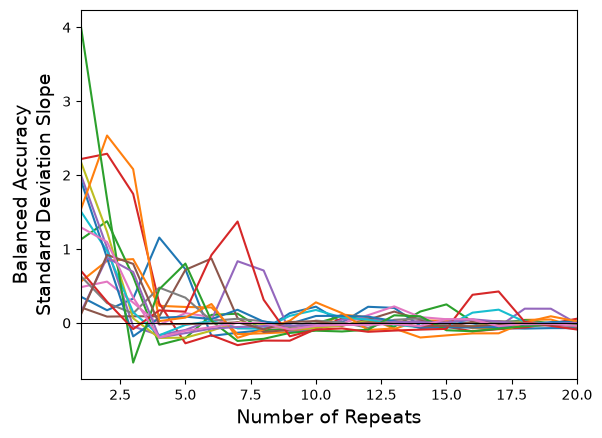

In [50]:
fig, ax = plt.subplots()

for m in bal_nopah:
    fig2, ax2 = plt.subplots()

    n_of_times = range(1, len(bal_nopah[m]) + 1)
    step_wise_stds = np.array([np.std(bal_nopah[m][:i]) for i in n_of_times])

    y_axis = np.gradient(step_wise_stds,n_of_times)

    ax2.plot(n_of_times, y_axis, marker='o')
    
    ax.plot(n_of_times, y_axis)

    ax2.set_xlabel('Number of Repeats', fontsize=14)
    ax2.set_ylabel('Balanced Accuracy\nStandard Deviation Slope', fontsize=14)
    ax2.set_xlim(min(n_of_times),max(n_of_times))

    ax2.axhline(0, lw=.7, c='k')  # Reference line at zero slope

    fig2.savefig(f'{plots_folder}/accuracy_std_vs_repeats/balanced_accuracy_std_slope_vs_repeats_{m.replace(" ", "_")}.png',
                 dpi=400, facecolor='#fff', bbox_inches='tight')

    plt.close()

ax.set_xlabel('Number of Repeats', fontsize=14)
ax.set_ylabel('Balanced Accuracy\nStandard Deviation Slope', fontsize=14)
ax.set_xlim(min(n_of_times),max(n_of_times))
ax.axhline(0, lw=.7, c='k')

fig.savefig(f'{plots_folder}/accuracy_std_vs_repeats/balanced_accuracy_std_slope_vs_repeats_all_models.png',
            dpi=400, facecolor='#fff', bbox_inches='tight')

In [51]:
nopah_accs_df = acc_df(nopah_models,raw_nopah,bal_nopah,chance_bal_nopah,
                       f'{csv_folder}/model_performance_comparison.csv')

In [52]:
comparison_plots(raw_nopah,bal_nopah,chance_bal_nopah,pah_yn=False,
                 close=True)

#### Class-wise

In [53]:
class_wise_df = []

for m in nopah_models:
    name = m
    if ' (R-U)' in name or '3D MSCC' in name:
        name = 'r-u_'+name.replace(' (R-U)','')
    else:
        name = 'non_r-u_'+name

    name = name.lower().replace(' (','_').replace(')','').replace(' ','_')
    name += '_classwiseaccuracies'

    files = glob.glob(f'{acc_folder}/{name}*')

    model_df = []
    for file in files:
        
        csv = pd.read_csv(file)

        if len(model_df) == 0:
            model_df = csv.copy()
        else:
            model_df = pd.concat((model_df,csv))

    mean = pd.DataFrame(model_df.mean(axis=0)).T
    std = pd.DataFrame(model_df.std(axis=0)).T
    median = pd.DataFrame(model_df.median(axis=0)).T

    model_df = {'model':m}
    for cat in mean.columns:
        model_df[cat] = mean[cat]
        model_df[f'{cat}_std'] = std[cat]
        model_df[f'{cat}_median'] = median[cat]

    model_df = pd.DataFrame(model_df)

    if len(class_wise_df) == 0:
        class_wise_df = model_df.copy()
    else:
        class_wise_df = pd.concat((class_wise_df,model_df))

class_wise_df.to_csv(f'{csv_folder}/class_wise_accuracy.csv',index=False)

#### Confusion Matrices

In [54]:
confmats = {x:[] for x in nopah_models}

for m in nopah_models:
    name = m
    if ' (R-U)' in name or '3D MSCC' in name:
        name = 'r-u_'+name.replace(' (R-U)','')
    else:
        name = 'non_r-u_'+name

    name = name.lower().replace(' (','_').replace(')','').replace(' ','_')
    name += '_confusionmatrix'

    files = glob.glob(f'{acc_folder}/{name}*')

    cats = []
    for file in files:
        csv = pd.read_csv(file)
        
        if len(cats)==0:
            cats = csv['Unnamed: 0'].to_list()

        confmats[m].append(csv.iloc[:,1:].to_numpy())

    confmats[m] = np.array(confmats[m])*100

    mean = np.mean(confmats[m],axis=0)
    std = np.std(confmats[m],axis=0)

    string_mat = plus_minus(mean,std)
    string_mat = np.reshape(string_mat,np.shape(mean))
    string_mat[np.where(string_mat=='0')]=''
    fig, ax = draw_confusion_matrix(mean,cats,
                                    text_matrix=string_mat,
                                    fontsize=8,textrot=45)
    fig.savefig(f'{plots_folder}/confusion_matrices/{m.lower().replace(' ','_')}_confusion_matrix.png',
                dpi=400, facecolor='#fff', bbox_inches='tight')
    ax.set_title(m)
    
    plt.close()

    combos = [[mean,'average'],
              [std,'std']]
    for combo in combos:
        to_df = pd.DataFrame(combo[0],columns=cats,index=cats)
        to_df.to_csv(f'{csv_folder}/confusion_matrices/{m.lower().replace(' ','_')}_{combo[1]}.csv')


### With PAHs

In [55]:
pah_models = [
    'GNB (U)',
    'Poly SVM (U)',
    'RBF SVM (U)',
    'kNN',
    'GNB (W)',
    'Poly SVM (W)',
    'RBF SVM (W)',
]
raw_pah = {x:[] for x in pah_models}
bal_pah = {x:[] for x in pah_models}
chance_bal_pah = {x:[] for x in pah_models}

#### Overall

In [56]:
chance = 1/7

for m in pah_models:
    name = 'with_pahs_' + m + '_accuracies'
    name = name.lower().replace(' (','_').replace(')','').replace(' ','_')


    files = glob.glob(f'{acc_folder}/{name}*')

    for file in files:
        csv = pd.read_csv(file)
        raw_pah[m] += csv['raw'].tolist()
        bal_pah[m] += csv['balanced'].tolist()

    raw_pah[m] = np.array(raw_pah[m])
    bal_pah[m] = np.array(bal_pah[m])

    raw_pah[m] *= 100
    bal_pah[m] *= 100

    chance_bal_pah[m] = np.array([(acc - chance*100) / (1 - chance) for acc in bal_pah[m]])

In [57]:
pah_accs_df = acc_df(pah_models,raw_pah,bal_pah,chance_bal_pah,
                     f'{csv_folder}/model_performance_comparison_with_pahs.csv')

In [58]:
comparison_plots(raw_pah,bal_pah,chance_bal_pah,pah_yn=True,
                 close=True)

#### Class-wise

In [59]:
class_wise_df = []

for m in pah_models:
    name = 'with_pahs_' + m + '_classwiseaccuracies'
    name = name.lower().replace(' (','_').replace(')','').replace(' ','_')

    files = glob.glob(f'{acc_folder}/{name}*')

    model_df = []
    for file in files:
        
        csv = pd.read_csv(file)

        if len(model_df) == 0:
            model_df = csv.copy()
        else:
            model_df = pd.concat((model_df,csv))

    mean = pd.DataFrame(model_df.mean(axis=0)).T
    std = pd.DataFrame(model_df.std(axis=0)).T
    median = pd.DataFrame(model_df.median(axis=0)).T

    model_df = {'model':m}
    for cat in mean.columns:
        model_df[cat] = mean[cat]
        model_df[f'{cat}_std'] = std[cat]
        model_df[f'{cat}_median'] = median[cat]

    model_df = pd.DataFrame(model_df)

    if len(class_wise_df) == 0:
        class_wise_df = model_df.copy()
    else:
        class_wise_df = pd.concat((class_wise_df,model_df))

class_wise_df.to_csv(f'{csv_folder}/class_wise_accuracy_with_pahs.csv',index=False)

#### Confusion Matrices

In [60]:
confmats = {x:[] for x in pah_models}

for m in pah_models:
    name = 'with_pahs_' + m + '_confusionmatrix'
    name = name.lower().replace(' (','_').replace(')','').replace(' ','_')

    files = glob.glob(f'{acc_folder}/{name}*')

    cats = []
    for file in files:
        csv = pd.read_csv(file)
        
        if len(cats)==0:
            cats = csv['Unnamed: 0'].to_list()

        confmats[m].append(csv.iloc[:,1:].to_numpy())

    confmats[m] = np.array(confmats[m])*100

    mean = np.mean(confmats[m],axis=0)
    std = np.std(confmats[m],axis=0)

    string_mat = plus_minus(mean,std)
    string_mat = np.reshape(string_mat,np.shape(mean))
    string_mat[np.where(string_mat=='0')]=''
    fig, ax = draw_confusion_matrix(mean,cats,
                                    text_matrix=string_mat,
                                    fontsize=8,textrot=45)
    fig.savefig(f'{plots_folder}/confusion_matrices/{m.lower().replace(' ','_')}_with_pahs_confusion_matrix.png',
                dpi=400, facecolor='#fff', bbox_inches='tight')
    ax.set_title(m)
    plt.close()

    combos = [[mean,'average'],
              [std,'std']]
    for combo in combos:
        to_df = pd.DataFrame(combo[0],columns=cats,index=cats)
        to_df.to_csv(f'{csv_folder}/confusion_matrices/{m.lower().replace(' ','_')}_with_pahs_{combo[1]}.csv')


## Merge $\phi_{\mathrm{BS}}$ data

In [90]:
bsl_dict = {
    'kNN':[],
    'GNB (W)':[],
    'Poly SVM (W)':[],
    'RBF SVM (W)':[],
}

In [91]:
for m in bsl_dict:
    name = m.replace(' (W)','').lower().replace(' (','_').replace(')','').replace(' ','_')
    files = glob.glob(f'{bsl_folder}/*{name}*')

    for file in files:
        with open(file) as f:
            bsl_dict[m].append(float(f.read()))

In [92]:
bsl_df = {
    'model':list(bsl_dict.keys()),
    'mean_bsl':[np.mean(bsl_dict[m]) for m in bsl_dict],
    'std_bsl':[np.std(bsl_dict[m]) for m in bsl_dict],
    'median_bsl':[np.median(bsl_dict[m]) for m in bsl_dict],
}
bsl_df = pd.DataFrame(bsl_df)
bsl_df.to_csv(f'{csv_folder}/bsl.csv',index=False)

In [102]:
bsl_dict

{'kNN': [0.22464229702561112,
  0.20355616274478452,
  0.26818134227730694,
  0.2244956099903332,
  0.27326924823991644,
  0.22297751342142544,
  0.23153684115034945,
  0.1929487566940369,
  0.1647387661484961,
  0.1841744830029459,
  0.2348304866036045,
  0.19887065173912805,
  0.2762066137110918,
  0.175052204565217,
  0.17514896457902204,
  0.2179753819632441,
  0.22034144274278947,
  0.20077518362522678,
  0.18662671723351282,
  0.20875681397647186],
 'GNB (W)': [0.09857382112313735,
  0.1336447100194759,
  0.12701739199193737,
  0.1411286264068445,
  0.14113305387122196,
  0.1433384587560678,
  0.10508510247722386,
  0.1315784942241039,
  0.1373595870089328,
  0.10380588411388159,
  0.11785612543738921,
  0.10809511680328268,
  0.10667055488392604,
  0.09852489708813249,
  0.10255485393094355,
  0.1009096641841733,
  0.11423590997904531,
  0.12250721364687692,
  0.10333027449335619,
  0.09671107352202435],
 'Poly SVM (W)': [0.08465627608133501,
  0.11069992918453499,
  0.100974402

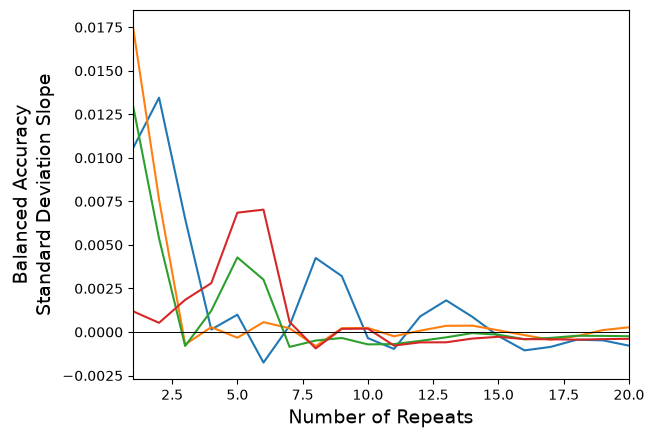

In [103]:
fig, ax = plt.subplots()

for m in bsl_dict:
    fig2, ax2 = plt.subplots()

    n_of_times = range(1, len(bsl_dict[m]) + 1)
    step_wise_stds = np.array([np.std(bsl_dict[m][:i]) for i in n_of_times])

    y_axis = np.gradient(step_wise_stds,n_of_times)

    ax2.plot(n_of_times, y_axis, marker='o')
    
    ax.plot(n_of_times, y_axis)

    ax2.set_xlabel('Number of Repeats', fontsize=14)
    ax2.set_ylabel('Balanced Accuracy\nStandard Deviation Slope', fontsize=14)
    ax2.set_xlim(min(n_of_times),max(n_of_times))

    ax2.axhline(0, lw=.7, c='k')  # Reference line at zero slope

    fig2.savefig(f'{plots_folder}/bsl_std_vs_repeats/bsl_std_slope_vs_repeats_{m.replace(" ", "_")}.png',
                 dpi=400, facecolor='#fff', bbox_inches='tight')

    plt.close()

ax.set_xlabel('Number of Repeats', fontsize=14)
ax.set_ylabel('Balanced Accuracy\nStandard Deviation Slope', fontsize=14)
ax.set_xlim(min(n_of_times),max(n_of_times))
ax.axhline(0, lw=.7, c='k')

fig.savefig(f'{plots_folder}/bsl_std_vs_repeats/bsl_std_slope_vs_repeats_all_models.png',
            dpi=400, facecolor='#fff', bbox_inches='tight')

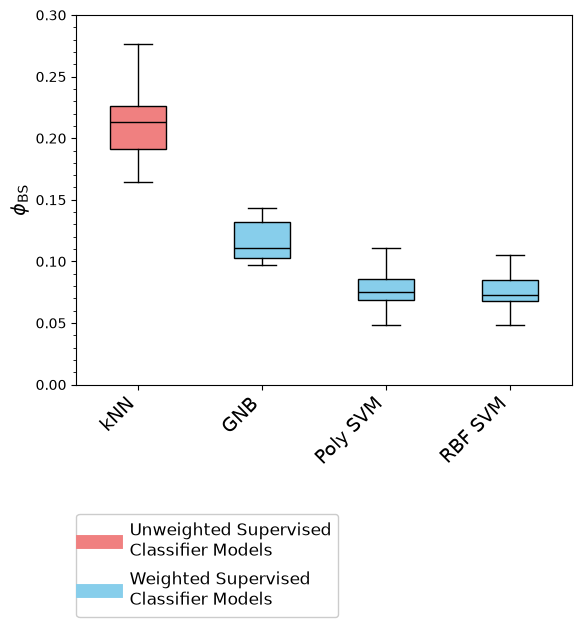

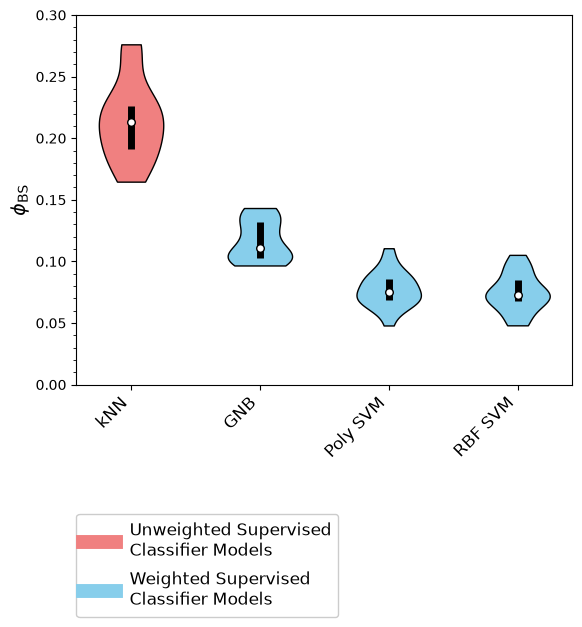

In [98]:
# Generate Brier Score Loss comparison plots


for plot_choice in plot_type:
        
    # Assign colors based on model type

    colours_to_use_bsl = [model_colour(x) for x in bsl_dict.keys()]
    # Create plot
    bsl_dict_for_plotting = {x.replace(' (W)',''):bsl_dict[x] for x in bsl_dict}
    fig, ax = plot_type[plot_choice](bsl_dict_for_plotting,
                                        ylabel='$\\phi_{\\mathrm{BS}}$',
                                        colours=colours_to_use_bsl)
    
    # Set y-axis limits appropriate for BSL
    sfc.set_axis_ticks(bsl_dict, ax, 'y', major_ticks_interval=0.05,
                        minor_ticks_interval=0.01, rounding=3,
                        upper_lim=0.30, lower_lim=0.05)
        
    # Add legend for model categories
    for c in boxplot_colors_dict:
        if boxplot_colors_dict[c] in colours_to_use_bsl:
            ax.plot([None], [None], c=boxplot_colors_dict[c], label=c, lw=10)

    ax.legend(framealpha=1, bbox_to_anchor=(0, -.35), loc='upper left', borderaxespad=0, fontsize=12)
    fig.savefig(f'{plots_folder}/bsl_comparison_with_pahs_{plot_choice}.svg',
                dpi=600, facecolor='#fff', bbox_inches='tight')